In [21]:
#Initial Data Cleaning

import pandas as pd
df = pd.read_csv("sanantonio.csv")

# 1. Removing vehicle-related columns

vehicle_cols = [
    "vehicle_color",
    "vehicle_make",
    "vehicle_model",
    "vehicle_registration_state",
    "vehicle_year",
    "contraband_found",
    "search_basis"
]

df = df.drop(columns=vehicle_cols, errors="ignore")

# 2. Remove rows with unknown race or sex

df = df[
    (df["subject_race"].str.lower() != "unknown") &
    (df["subject_sex"].str.lower() != "unknown") &
    (df["subject_sex"].str.upper() != "NA")
]

# 3. Filter data to years 2014–2020

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df[
    (df["date"].dt.year >= 2014) &
    (df["date"].dt.year <= 2019)
]

df = df.sort_values(by="date")

# 4. Save cleaned dataset - renaming it
df.to_csv("new2_san_antonio.csv", index=False)

print("✅ Data cleaning complete. Saved as new_san_antonio.csv")
print("Final shape:", df.shape)


/var/folders/17/gn14vdy96tz9ns2yjy1gmslw0000gn/T/ipykernel_23551/2194648865.py:2: DtypeWarning: Columns (17,19,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sanantonio.csv")


✅ Data cleaning complete. Saved as new_san_antonio.csv
Final shape: (880810, 26)


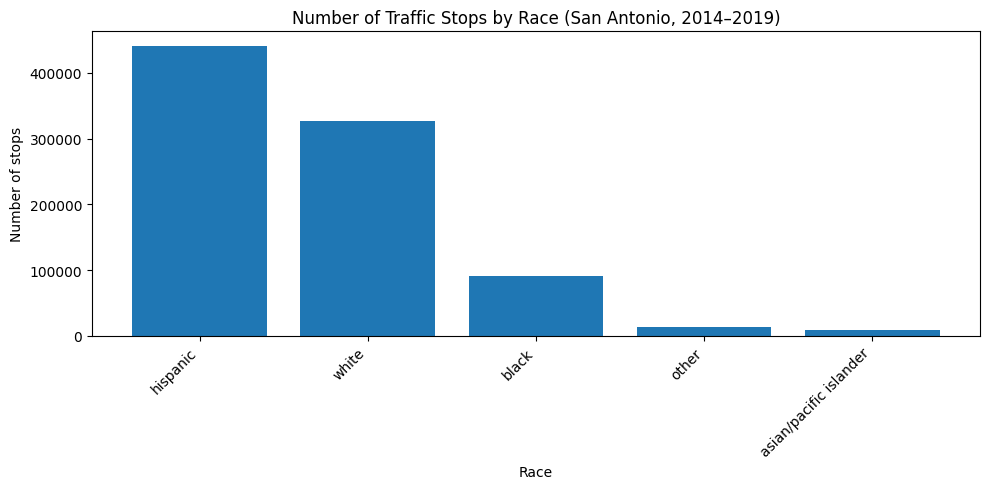

In [15]:
# Counting Number of traffic stops

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("new_san_antonio.csv")

# Count total stops by race
race_counts = df["subject_race"].value_counts()

# Plot (categorical histogram = bar chart)
plt.figure(figsize=(10, 5))
plt.bar(race_counts.index.astype(str), race_counts.values)
plt.xlabel("Race")
plt.ylabel("Number of stops")
plt.title("Number of Traffic Stops by Race (San Antonio, 2014–2019)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



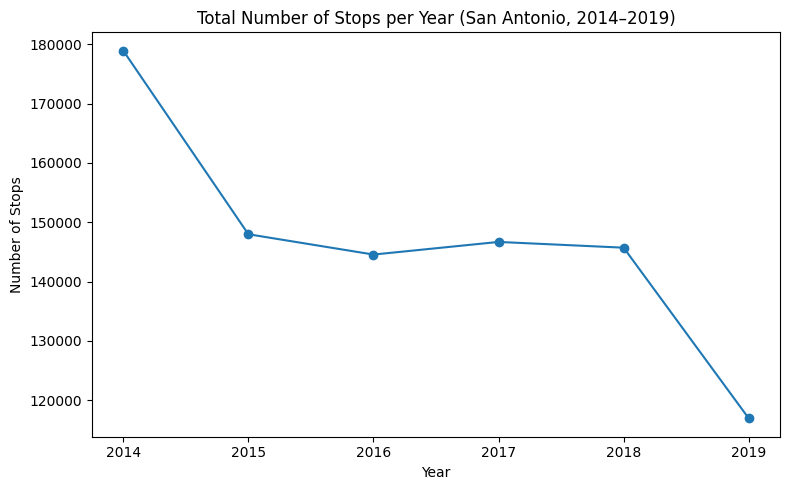

In [16]:
# Making a simple timeplot

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("new_san_antonio.csv")

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Create year column
df["year"] = df["date"].dt.year

# Count stops per year
year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Stops")
plt.title("Total Number of Stops per Year (San Antonio, 2014–2019)")
plt.xticks(year_counts.index)
plt.tight_layout()
plt.show()


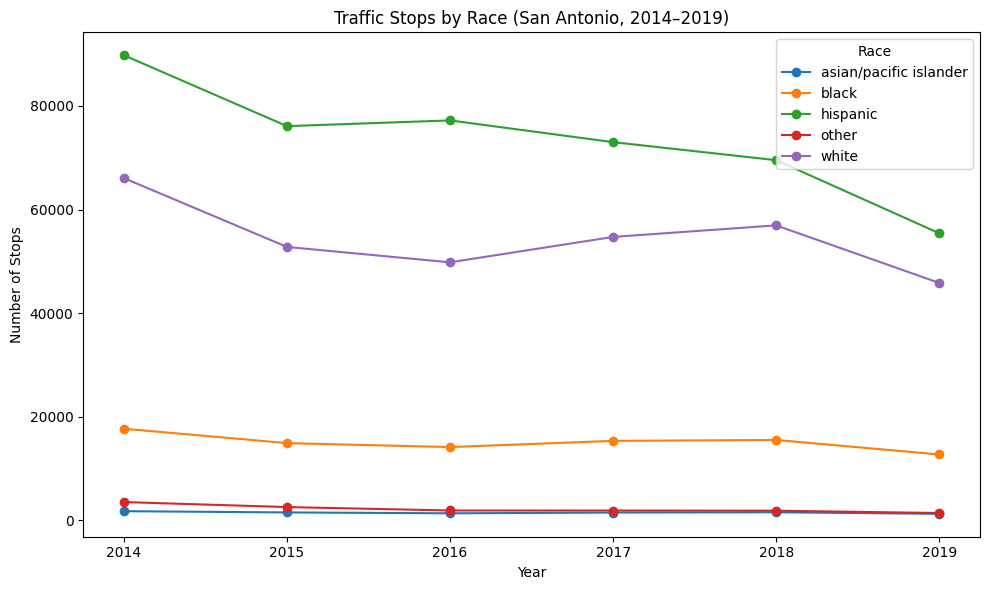

In [17]:
# Making my initial plot with the races

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("new_san_antonio.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Create year column
df["year"] = df["date"].dt.year

# Group by year and race, count stops
year_race_counts = (
    df.groupby(["year", "subject_race"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

# Plot time series by race
plt.figure(figsize=(10, 6))

for race in year_race_counts.columns:
    plt.plot(year_race_counts.index, year_race_counts[race], marker="o", label=race)

plt.xlabel("Year")
plt.ylabel("Number of Stops")
plt.title("Traffic Stops by Race (San Antonio, 2014–2019)")
plt.xticks(year_race_counts.index)
plt.legend(title="Race")
plt.tight_layout()
plt.show()


In [19]:
# Seeing the difference and how many rows it removed

import pandas as pd

# Load datasets
old_df = pd.read_csv("sanantonio.csv")
new_df = pd.read_csv("new_san_antonio.csv")

# Convert date columns
old_df["date"] = pd.to_datetime(old_df["date"], errors="coerce")
new_df["date"] = pd.to_datetime(new_df["date"], errors="coerce")

# Filter to year 2020
old_2019 = old_df[old_df["date"].dt.year == 2019]
new_2019 = new_df[new_df["date"].dt.year == 2019]

# Count stops
old_count = len(old_2019)
new_count = len(new_2019)

# Print comparison
print("2020 Stop Counts Comparison")
print(f"Original dataset (sanantonio.csv): {old_count}")
print(f"Cleaned dataset (new_san_antonio.csv): {new_count}")
print(f"Difference (removed during cleaning): {old_count - new_count}")


/var/folders/17/gn14vdy96tz9ns2yjy1gmslw0000gn/T/ipykernel_23551/2269940871.py:4: DtypeWarning: Columns (17,19,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  old_df = pd.read_csv("sanantonio.csv")


2020 Stop Counts Comparison
Original dataset (sanantonio.csv): 117371
Cleaned dataset (new_san_antonio.csv): 116956
Difference (removed during cleaning): 415


In [23]:
#getting it's shape

import pandas as pd

# Load the dataset
df = pd.read_csv("san_antonio_cleaned.csv")

# Print shape (rows, columns)
print("Dataset shape:", df.shape)


Dataset shape: (880810, 26)


In [24]:
# Count number of 1s
arrest_ones = (df["arrest_made"] == 1).sum()
search_ones = (df["search_conducted"] == 1).sum()

print("Number of arrests (1s):", arrest_ones)
print("Number of searches (1s):", search_ones)

# Also print proportions
print("Arrest rate:", arrest_ones / len(df))
print("Search rate:", search_ones / len(df))

Number of arrests (1s): 2203
Number of searches (1s): 7687
Arrest rate: 0.0025011069356614935
Search rate: 0.008727194287076669


In [26]:
# Getting Percent of arrests involving Hispanic drivers


hispanic_arrest_percent = (
    df[df["arrest_made"] == 1]["raw_race_H"].mean() * 100
)

print("Percent of arrests involving Hispanic drivers:", hispanic_arrest_percent)

Percent of arrests involving Hispanic drivers: 45.61960962324104


In [28]:
# Getting Percent of searches involving Hispanic drivers

hispanic_search_percent = (
    df[df["search_conducted"] == 1]["raw_race_H"].mean() * 100
)

print("Percent of searches involving Hispanic drivers:", hispanic_search_percent)

Percent of searches involving Hispanic drivers: 44.62078834395733
